Clustering

What is Clustering? (English + বাংলা)

Clustering is an unsupervised machine learning technique used to group similar data points together.

👉 No labels are given — the model finds patterns on its own.

🧠 Simple Idea (English)
Data points that are similar → same group (cluster)
Data points that are different → different clusters
📘 সহজভাবে (বাংলায়)

Clustering মানে হলো — মিল আছে এমন ডেটাগুলোকে একসাথে গ্রুপ করা।

👉 এখানে আগে থেকে কোনো label (output) দেওয়া থাকে না।

🎯 Example

Imagine:

Students grouped by study habits
Customers grouped by buying behavior

K-Means Clustering (English + বাংলা)
🔵 What is K-Means?


K-Means is an unsupervised machine learning algorithm that divides data into K clusters based on similarity.

বাংলা:
K-Means হলো একটি unsupervised algorithm, যা ডেটাকে Kটি গ্রুপে ভাগ করে similarity অনুযায়ী।

🧠 Steps (English)
Choose number of clusters K
Initialize K centroids randomly
Assign each point to the nearest centroid
Update centroids (mean of points)
Repeat until centroids stop changing
📘 ধাপে ধাপে (বাংলা)
আগে K (cluster সংখ্যা) নির্ধারণ করো
random centroid নেওয়া হয়
প্রতিটি point → nearest centroid এ assign করা হয়
centroid update হয় (average নিয়ে)
এই process বারবার চলে যতক্ষণ না stable হয়
🧮 Objective Function (Important)

English: Minimize distance between points and their cluster center
বাংলা: প্রতিটি point আর centroid-এর দূরত্ব কমানোই লক্ষ্য

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import collections    #For fetching dictionary of labels & clusters
import nltk           #Natural Language Toolkit
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk import word_tokenize #Word tokenization is the process of splitting a large sample of text into words.
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer #Normalizing Sentences
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from pprint import pprint #print complex data structures in a clean and readable format
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\naimul.islam\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\naimul.islam\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\naimul.islam\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


What is NLTK?

English:
NLTK (Natural Language Toolkit) is a powerful Python library used for processing and analyzing human language (text).

বাংলা:
NLTK হলো একটি Python library যা মানুষের ভাষা (text) প্রসেস ও বিশ্লেষণ করার জন্য ব্যবহার করা হয়।

🎯 Why NLTK is Used?

English:

Text preprocessing
NLP research & learning
Building models like classification, clustering

বাংলা:

টেক্সট পরিষ্কার করা (preprocessing)
NLP শেখা ও গবেষণা
classification / clustering model বানানো

⚙️ Main Features of NLTK
1. 🔹 Tokenization

English: Split text into words or sentences
বাংলা: বাক্যকে শব্দে ভাগ করা

from nltk.tokenize import word_tokenize
word_tokenize("I love AI")


2. 🔹 Stopwords Removal

English: Remove common useless words
বাংলা: অপ্রয়োজনীয় শব্দ বাদ দেওয়া

from nltk.corpus import stopwords
stopwords.words('english')


3. 🔹 Stemming

English: Reduce words to root form
বাংলা: শব্দকে ছোট root form এ আনা

from nltk.stem import PorterStemmer
ps = PorterStemmer()
ps.stem("running")

4. 🔹 Lemmatization (Better than stemming)

English: Converts word to meaningful base form
বাংলা: শব্দকে সঠিক base form এ আনে

from nltk.stem import WordNetLemmatizer

5. 🔹 Part of Speech (POS) Tagging

English: Identifies grammar roles (noun, verb, etc.)
বাংলা: শব্দের ধরন চিহ্নিত করে

import nltk
nltk.pos_tag(word_tokenize("I love AI"))

6. 🔹 Named Entity Recognition (NER)

English: Finds names, places, organizations
বাংলা: ব্যক্তি, স্থান, প্রতিষ্ঠান চিনে

7. 🔹 Frequency Distribution

English: Counts word frequency
বাংলা: শব্দ কতবার এসেছে তা গণনা

from nltk import FreqDist

Load Dataset

In [3]:
sentences=pd.read_csv('KMC/Quotes.csv')
sentences

,Quotes
0,Graphics designers are most creative people
1,Artificial Intelligence or AI is the last inve...
2,Snooker is a billiards sport for normally two ...
3,Snooker is played on a large (12 feet by 6 fee...
4,FOREX is the stock market for trading currencies
5,Software Engineering is hotter and hotter topi...
6,Love is blind
7,Snooker is popular in the United Kingdom and m...
8,The flying or operating of aircraft is known a...
9,AI is likely to be either the best or worst th...



Converting our dataframe into List

In [4]:
sentences_list = sentences["Quotes"].tolist()

In [5]:
sentences_list

['Graphics designers are most creative people',
 'Artificial Intelligence or AI is the last invention - humans could ever make',
 'Snooker is a billiards sport for normally two players.',
 'Snooker is played on a large (12 feet by 6 feet) table that is covered with a smooth green material.',
 'FOREX is the stock market for trading currencies',
 'Software Engineering is hotter and hotter topic in Silicon Valley',
 'Love is blind',
 'Snooker is popular in the United Kingdom and many other countries',
 'The flying or operating of aircraft is known as aviation.',
 'AI is likely to be either the best or worst thing happen to humanity',
 'Design is Intelligence made visible.',
 'Falling in love is like being on drugs.',
 'There is only one happiness in Life to Love and to be loved.',
 "Boeing 777 is considered world's largest economical plane in the world of Aviation.",
 'Warren Buffet is famous for making good investments.He knows stock markets',
 'The biggest of the many uses of aviation a


Defining a function tokenizer(text)

In [6]:
def tokenizer(text):
  tokens = word_tokenize(text) #Word tokenization is the process of splitting a large sample of text into words.
  stemmer = PorterStemmer()

  #Removing Morphhological axes
  tokens = [stemmer.stem(t) for t in tokens if t not in stopwords.words('english')]   #removes stopwords + applies stemming + creates new token list
  return tokens

Defining a function cluster_sentences(sentences,k=(int))
1. Training our K - Means Model
2. Creating tfidf Vectorizer Matrix

In [7]:
def cluster_sentences(sentences_list, k):

  #Create tf ifd again: stopwords--> we filter out common words (I,my, the,and...)
  tfidf_vectorizer = TfidfVectorizer(tokenizer=tokenizer, stop_words=stopwords.words('english'),lowercase=True)

  #builds a tf-idf matrix for the sentences
  #   Transforms text to feature vectors that can be used as input to estimator.
  tfidf_matrix = tfidf_vectorizer.fit_transform(sentences_list)

  kmeans = KMeans(n_clusters=k)
  kmeans.fit(tfidf_matrix)

  clusters = collections.defaultdict(list)

  for i, label in enumerate(kmeans.labels_):      # i=index, label=cluster number
    clusters[label].append(i)                     # text কে তার cluster এ যোগ করে

  return dict(clusters)


Testing our Model

In [8]:
k = 7
clusters = cluster_sentences(sentences_list,k)
for cluster in range (k):
  print("\nCLUSTER ",cluster,":\n")
  for i, sentence in enumerate(clusters[cluster]):
    print("\t",(i+1),": ",sentences_list[sentence])

C:\Users\naimul.islam\PyCharmMiscProject\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
C:\Users\naimul.islam\PyCharmMiscProject\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ["'d", "'ll", "'m", "'re", "'s", "'ve", 'could', 'might', 'must', "n't", 'need', 'sha', 'wo', 'would'] not in stop_words.
  warnings.warn(



CLUSTER  0 :

	 1 :  Software Engineering is hotter and hotter topic in Silicon Valley
	 2 :  All giant majors in Silicon Valley is focusing AI for their business productivity
	 3 :  Software Engineer has average salary of $170K at Google

CLUSTER  1 :

	 1 :  AI is likely to be either the best or worst thing happen to humanity
	 2 :  Falling in love is like being on drugs.

CLUSTER  2 :

	 1 :  Graphics designers are most creative people
	 2 :  Graphics Designing is high rated freelance subject
	 3 :  AI would have a low error rate compared to humans if coded properly. 

CLUSTER  3 :

	 1 :  Snooker is popular in the United Kingdom and many other countries
	 2 :  The flying or operating of aircraft is known as aviation.
	 3 :  Boeing 777 is considered world's largest economical plane in the world of Aviation.
	 4 :  The biggest of the many uses of aviation are in air travel and military aircraft.
	 5 :  Aviation refers to flying using an aircraft like an aeroplane.
	 6 :  Auomation i

DBSCAN — Explained (English + বাংলা)

DBSCAN = Density-Based Spatial Clustering of Applications with Noise
It groups data based on density (how closely points are packed together).

বাংলা:
DBSCAN হলো একটি clustering algorithm, যা ডেটার ঘনত্ব (density) দেখে group করে।

🧠 Simple Idea
Dense area → cluster
Sparse area → noise (outlier)

👉 No need to choose number of clusters (K) ❗

📊 Visualization
⚙️ Important Parameters
🔹 1. eps (epsilon)

English:
Maximum distance between two points

বাংলা:
দুইটা point কত দূরে হলে neighbour ধরা হবে

🔹 2. min_samples

English:
Minimum points to form a cluster

বাংলা:
cluster বানাতে minimum কয়টা point লাগবে

In [9]:
#Importing Libraries
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn import datasets
import numpy as np


In [10]:
x,y = datasets.make_moons(n_samples=2500, noise= 0.05)

x1 = x[:,0]
x2 = x[:,1]

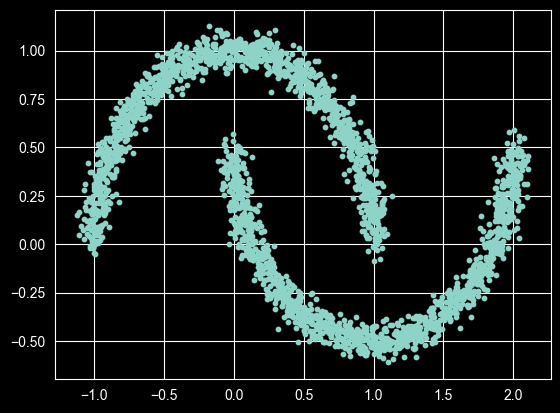

In [11]:
plt.scatter(x1,x2,s=5)
plt.show()

In [12]:
neigh = NearestNeighbors(n_neighbors=2)
nbrs = neigh.fit(x)
distances, indices = nbrs.kneighbors(x)

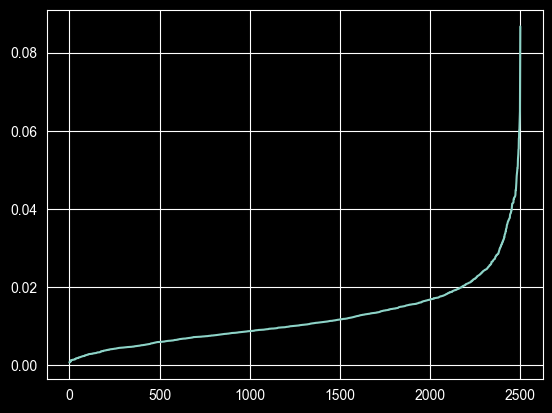

In [13]:
distances = np.sort(distances, axis=0)
distances = distances[:,1]
plt.plot(distances)

In [14]:
model = DBSCAN(eps = 0.050)
model=model.fit(x)
y_pred = model.labels_.astype(int)

Clusters:



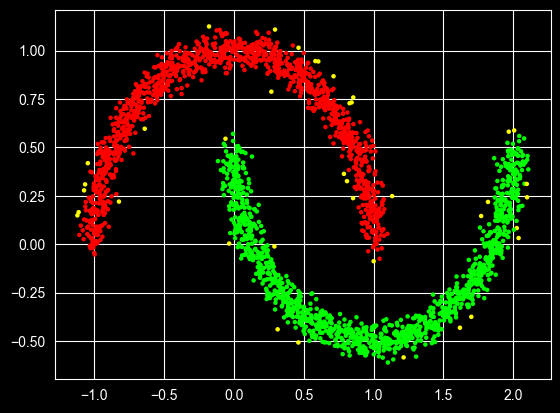

In [15]:
colors = np.array(['#ff0000','#00ff00','#0000ff','#ffff00'])
print("Clusters:\n")
plt.scatter(x1,x2,s=5,color = colors [y_pred])
plt.show()

In [16]:
print(confusion_matrix(y,y_pred))
print(accuracy_score(y,y_pred)*100)

[[   0    0    0]
 [  22 1228    0]
 [  16    0 1234]]
98.48


Hierarchical Clustering (English + বাংলা)?

English:
Hierarchical Clustering builds a tree-like structure (dendrogram) to group data step by step.

বাংলা:
Hierarchical Clustering ডেটাকে ধাপে ধাপে tree (dendrogram) আকারে group করে।

🧠 Simple Idea

👉 Small clusters → gradually merge → big cluster

👉 Or reverse:
👉 Big cluster → divide → smaller clusters

📊 Visualization (Dendrogram)
🔑 Types of Hierarchical Clustering
1. 🔼 Agglomerative (Bottom-Up)

English:

Start with each point as a cluster
Merge closest clusters

বাংলা:

শুরুতে প্রতিটি point আলাদা cluster
তারপর কাছেরগুলো merge হয়
2. 🔽 Divisive (Top-Down)

English:

Start with one big cluster
Split into smaller clusters

বাংলা:

শুরুতে সব data এক cluster
তারপর ভাগ করা হয়
⚙️ How it works (Agglomerative)
Start with individual points
Find closest pair
Merge them
Repeat until one cluster

In [17]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.datasets import make_blobs
import numpy as np

linkage → performs hierarchical clustering
dendrogram → draws tree diagram

In [18]:
x,y = make_blobs(n_samples=50)

In [19]:
x1 = x[:,0]
x2 = x[:,1]

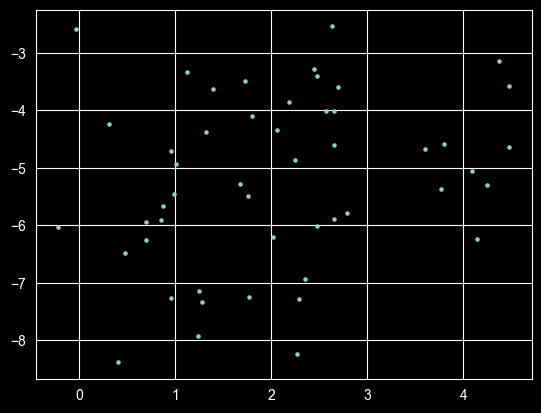

In [20]:
plt.scatter(x1,x2,s=5)

plt.show()

In [21]:
linkage_matrix = linkage(x,"complete")
print(linkage_matrix)

[[2.00000000e+01 2.10000000e+01 8.25119894e-02 2.00000000e+00]
 [3.30000000e+01 3.80000000e+01 1.27437778e-01 2.00000000e+00]
 [7.00000000e+00 2.50000000e+01 1.61886693e-01 2.00000000e+00]
 [1.80000000e+01 3.70000000e+01 1.85494440e-01 2.00000000e+00]
 [3.00000000e+01 4.20000000e+01 1.89590738e-01 2.00000000e+00]
 [3.00000000e+00 3.40000000e+01 2.20343767e-01 2.00000000e+00]
 [2.60000000e+01 2.80000000e+01 2.26543417e-01 2.00000000e+00]
 [3.90000000e+01 4.60000000e+01 2.29688301e-01 2.00000000e+00]
 [1.30000000e+01 1.60000000e+01 2.45518377e-01 2.00000000e+00]
 [3.20000000e+01 4.40000000e+01 2.91855165e-01 2.00000000e+00]
 [4.70000000e+01 4.80000000e+01 3.20076382e-01 2.00000000e+00]
 [6.00000000e+00 5.40000000e+01 3.29285396e-01 3.00000000e+00]
 [1.00000000e+01 1.10000000e+01 3.56554451e-01 2.00000000e+00]
 [3.60000000e+01 4.50000000e+01 3.62529192e-01 2.00000000e+00]
 [2.00000000e+00 2.70000000e+01 3.69565938e-01 2.00000000e+00]
 [1.00000000e+00 5.30000000e+01 3.95134956e-01 3.000000

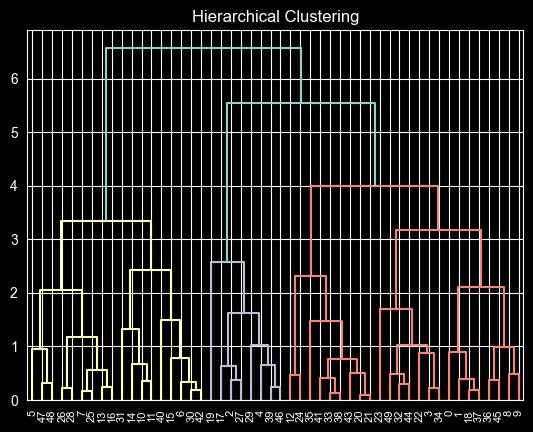

In [22]:
dendrogram = dendrogram(linkage_matrix,truncate_mode=None)
plt.title("Hierarchical Clustering")
plt.show()